In [25]:
pip install qutip

Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [27]:
import numpy as np
from pylab import *
import matplotlib.pyplot as plt
from qutip import *
import math
import itertools
import networkx as nx

## Qu-Quarts

In [28]:
# Define single qubit basis states
qubit_0 = basis(2, 0)  # |0⟩
qubit_1 = basis(2, 1)  # |1⟩

# Create the 4 basis states of the ququart
ququart_00 = tensor(qubit_0, qubit_0)  # |00⟩
ququart_01 = tensor(qubit_0, qubit_1)  # |01⟩
ququart_10 = tensor(qubit_1, qubit_0)  # |10⟩
ququart_11 = tensor(qubit_1, qubit_1)  # |11⟩

print("Ququart basis states:\n")
for i, state in enumerate([ququart_00, ququart_01, ququart_10, ququart_11]):
    print(f"|{i:02b}⟩ = {state.dag()}")

Ququart basis states:

|00⟩ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[1. 0. 0. 0.]]
|01⟩ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[0. 1. 0. 0.]]
|10⟩ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[0. 0. 1. 0.]]
|11⟩ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[0. 0. 0. 1.]]


In [29]:
#Making a QuQuart

quart_state1 = Qobj([[1, 0, 1, 0]]) # |bra>
quart_state2 = Qobj([[1, 1, 0, 0]]).trans() # <ket|


print(quart_state1)
print(quart_state2)

print(f"\nInner Product: {quart_state1 * quart_state2}")
print(f"\nOuter Product: {quart_state2 * quart_state1}")

Quantum object: dims=[[1], [4]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[1. 0. 1. 0.]]
Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [1.]
 [0.]
 [0.]]

Inner Product: (1+0j)

Outer Product: Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=CSR, isherm=False
Qobj data =
[[1. 0. 1. 0.]
 [1. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Control: Brute Force Strategy w/ 4-Qubit Systems

In [30]:
                    # --------------------------------------------------------------------------------- #
                    # BRUTE FORCE STRATEGY (OPTIMAL FOR 4-QUBIT SYSTEMS, WILL FAIL PAST THIS THRESHOLD) #
                    # --------------------------------------------------------------------------------- #

# ----------------------- 1. CREATING INTERSECTION GRAPH --------------------------------#

# Graph representation is as follows:
# - Nodes: represent invidiual qubits
# - Edges: represent 2-qubit gates, w/ edge weight representing # of gates between those qubits in total

G = nx.Graph()


qubits = ['q0', 'q1', 'q2', 'q3'] # node list (can be modified based on a given graph)
# defining qubit-qubit intersections w/ format (qubit A, qubit B, # gates acting on both)
interactions = [
    ('q0', 'q1', 4),
    ('q1', 'q2', 0),
    ('q2', 'q3', 3),
    ('q0', 'q3', 6)
]

G.add_nodes_from(qubits)
for q1, q2, weight in interactions:
    G.add_edge(q1, q2, weight=weight)

# ----------------------- 2. GENERATING ALL VALID MAPPINGS -------------------------------- #

def generate_pairings(qubits): # fctn generates all unique qubit mappings (pairs of size 2 in case of 4-qubit system)
    pairings = []

    for pair in itertools.combinations(qubits, 2):
        remaining = [q for q in qubits if q not in pair]
        second_pair = tuple(remaining)
        pairing = tuple(sorted((tuple(sorted(pair)), tuple(sorted(second_pair))))) # sort to avoid duplicates
        pairings.append(pairing)
    return list(set(pairings))
    
pairings = generate_pairings(qubits)

# ----------------------- 3. COUNT CROSS-QUQUART GATES FOR EACH MAPPING -------------------------------- #

def cross_ququart_cost(pairing, graph): # fctn that computes # of cross-ququart gates

    # Map each qubit to a ququart ID (2 total ququarts for 4-qubit system; IDs = [0, 1])
    ququart_map = {}
    for i, ququart in enumerate(pairing):
        for qubit in ququart:
            ququart_map[qubit] = i
    cost = 0

    for q1, q2, data in graph.edges(data=True):
        # If qubits belong to different ququarts → cross gate
        if ququart_map[q1] != ququart_map[q2]:
            cost += data['weight']
            
    return cost

# ----------------------- 4. CALCULATE OPTIMAL MAPPING -------------------------------- #

best_pairing = None
best_cost = float('inf') # 'inf' = +infinity (best-cost default)

for pairing in pairings:
    cost = cross_ququart_cost(pairing, G)
    print(f"Pairing {pairing} → Cross-ququart gates: {cost}")

    if cost < best_cost:
        best_cost = cost
        best_pairing = pairing

print("\n Optimal ququart mapping:")
print(best_pairing)
print(f"Minimum cross-ququart gates: {best_cost}")


Pairing (('q0', 'q1'), ('q2', 'q3')) → Cross-ququart gates: 6
Pairing (('q0', 'q3'), ('q1', 'q2')) → Cross-ququart gates: 7
Pairing (('q0', 'q2'), ('q1', 'q3')) → Cross-ququart gates: 13

 Optimal ququart mapping:
(('q0', 'q1'), ('q2', 'q3'))
Minimum cross-ququart gates: 6


## Test: Kernighan-Lin Graph Partitioning Strategy

In [31]:
from networkx.algorithms.community import kernighan_lin_bisection

# --------------------------------------------------------------------------------- #
# KERNIGHAN–LIN GRAPH PARTITIONING STRATEGY (SCALABLE, HEURISTIC, N-QUBIT SYSTEMS)     #
# --------------------------------------------------------------------------------- #

# ----------------------- 0. CONFIGURATION ------------------------------------------ #

NUM_QUBITS = 8                                   # total number of qubits (scales to hundreds)
QUBITS = [f"q{i}" for i in range(NUM_QUBITS)]    # node labels

# ----------------------- 1. CREATING INTERACTION GRAPH ----------------------------- #

# Graph representation:
# - Nodes: represent individual qubits
# - Edges: represent 2-qubit gates
# - Edge weight: total number of gates between those qubits

G = nx.Graph()
G.add_nodes_from(QUBITS)

# create intersections array (allowed to create more dense, conflicting interaction structure than was possible w/ brute force)
interactions = [
    ('q0', 'q1', 8),
    ('q1', 'q2', 6),
    ('q2', 'q3', 7),
    ('q4', 'q5', 9),
    ('q5', 'q6', 6),
    ('q6', 'q7', 8),
    ('q0', 'q4', 4),
    ('q1', 'q5', 5),
    ('q2', 'q6', 4),
    ('q3', 'q7', 5),
    ('q0', 'q6', 3),
    ('q1', 'q7', 2),
    ('q3', 'q4', 3),
    ('q0', 'q2', 5),
    ('q1', 'q3', 4),
    ('q4', 'q6', 5),
    ('q5', 'q7', 4),
    ('q0', 'q3', 2),
    ('q2', 'q5', 2),
    ('q1', 'q4', 1),
    ('q3', 'q6', 1),
]

# Add weighted edges to graph
for q1, q2, weight in interactions:
    G.add_edge(q1, q2, weight=weight)

# ----------------------- 2. BALANCED GRAPH PARTITIONING ----------------------------- #

# Apply Kernighan–Lin heuristic:
# - Produces two equal-size partitions
# - Minimizes weighted edge cut between partitions
# - Heuristic (not globally optimal, but scalable)

partition_A, partition_B = kernighan_lin_bisection(
    G,
    weight='weight'
)

# ----------------------- 3. COUNT CROSS-QUQUART GATES ------------------------------- #

def cross_ququart_cost(graph, A, B): # computes total # of gates acting across ququarts
    cost = 0

    for u, v, data in graph.edges(data=True):
        # Edge contributes if it crosses the partition
        if (u in A and v in B) or (u in B and v in A):
            cost += data['weight']

    return cost

cost = cross_ququart_cost(G, partition_A, partition_B)

# ----------------------- 4. OUTPUT PARTITION RESULTS -------------------------------- #

print("\n================= PARTITION RESULT =================")
print("Ququart 0:", sorted(partition_A))
print("Ququart 1:", sorted(partition_B))
print("Cross-ququart gate cost:", cost)
print("====================================================")



================= PARTITION RESULT =================
Ququart 0: ['q4', 'q5', 'q6', 'q7']
Ququart 1: ['q0', 'q1', 'q2', 'q3']
Cross-ququart gate cost: 30


## Test: Three Algorithm Aggregate Version


================ RANDOM CIRCUIT ================
Qubits: 14
Total 2-qubit gates: 38
Distinct interacting pairs: 32

================ RESULTS =================

--- Kernighan-Lin ---
Cut Cost: 37
Partition A: {'q1', 'q4', 'q9', 'q11', 'q12', 'q10', 'q13'}
Partition B: {'q2', 'q8', 'q6', 'q5', 'q3', 'q0', 'q7'}


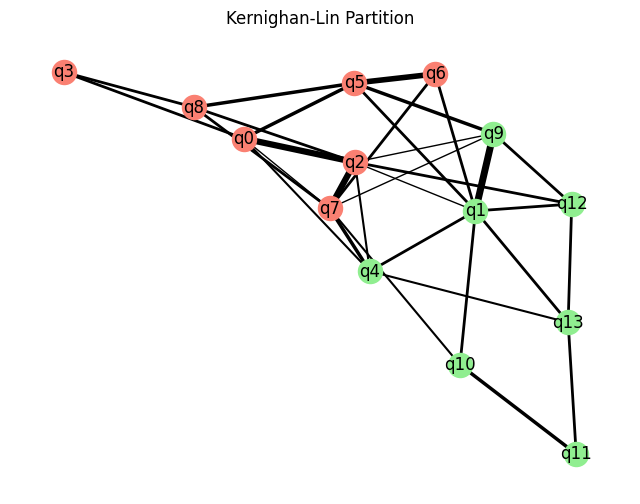


--- Spectral ---
Cut Cost: 64
Partition A: {'q1', 'q2', 'q10', 'q0', 'q11', 'q12', 'q13'}
Partition B: {'q8', 'q5', 'q3', 'q7', 'q4', 'q6', 'q9'}


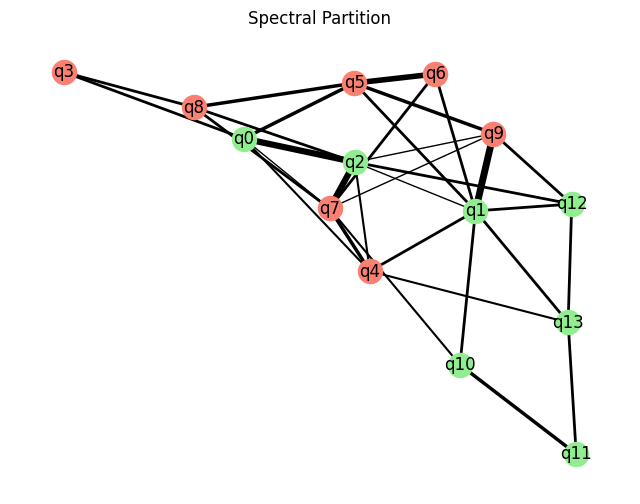


--- Fiduccia-Mattheyses ---
Cut Cost: 63
Partition A: {'q1', 'q2', 'q0', 'q7', 'q9', 'q12', 'q13'}
Partition B: {'q8', 'q5', 'q3', 'q10', 'q4', 'q6', 'q11'}


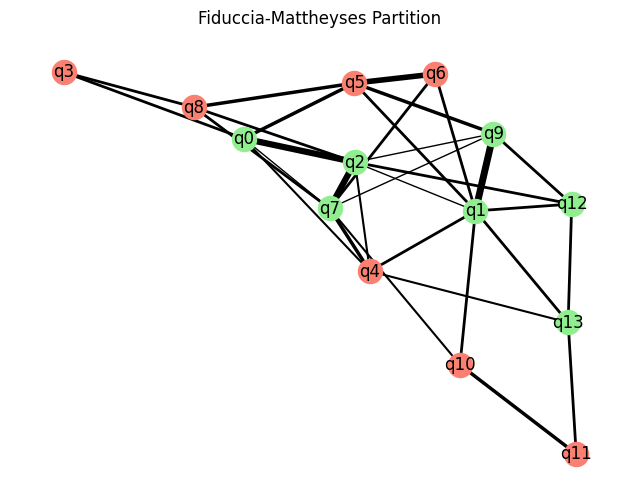


Best Algorithm: Kernighan-Lin
Best Cut Cost: 37


In [36]:
# =============================================================================
# LOCKED QUQUART MAPPING EXPERIMENT
# (No NumPy sum conflicts. No generator ambiguity.)
# Algorithms:
#   - Kernighan–Lin
#   - Spectral
#   - Fiduccia–Mattheyses
# =============================================================================

import random
import builtins
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =============================================================================
# GATE WEIGHTS
# =============================================================================

GATE_WEIGHTS = {
    "CNOT": 3,
    "CZ": 2,
    "SWAP": 5,
    "iSWAP": 4
}

# =============================================================================
# RANDOM CIRCUIT GENERATION
# =============================================================================

def generate_random_circuit(min_qubits=6, max_qubits=14,
                            min_gates=20, max_gates=60):

    n = random.choice([q for q in range(min_qubits, max_qubits + 1) if q % 2 == 0])
    qubits = [f"q{i}" for i in range(n)]

    interactions = defaultdict(lambda: defaultdict(int))
    num_gates = random.randint(min_gates, max_gates)

    for _ in range(num_gates):
        q1, q2 = random.sample(qubits, 2)
        gate = random.choice(list(GATE_WEIGHTS.keys()))
        key = tuple(sorted((q1, q2)))
        interactions[key][gate] += 1

    return qubits, interactions


# =============================================================================
# BUILD INTERACTION GRAPH
# =============================================================================

def build_interaction_graph(qubits, interactions):

    G = nx.Graph()
    G.add_nodes_from(qubits)

    for (q1, q2), gate_dict in interactions.items():

        # 🔒 Force builtin sum + force list conversion
        weighted_terms = [
            GATE_WEIGHTS[g] * c
            for g, c in gate_dict.items()
        ]

        weight = builtins.sum(weighted_terms)

        G.add_edge(q1, q2, weight=weight)

    return G


# =============================================================================
# CUT COST
# =============================================================================

def cut_cost(graph, A, B):

    weights = [
        data["weight"]
        for u, v, data in graph.edges(data=True)
        if (u in A and v in B) or (u in B and v in A)
    ]

    return builtins.sum(weights)


# =============================================================================
# SPECTRAL PARTITIONING
# =============================================================================

def spectral_partition(graph):

    L = nx.laplacian_matrix(graph, weight="weight").todense()
    eigenvalues, eigenvectors = np.linalg.eigh(L)

    fiedler_vector = np.array(eigenvectors[:, 1]).flatten()
    nodes = list(graph.nodes())

    A, B = set(), set()

    for i, node in enumerate(nodes):
        if fiedler_vector[i] >= 0:
            A.add(node)
        else:
            B.add(node)

    # Enforce balance strictly
    if abs(len(A) - len(B)) > 1:
        nodes_sorted = sorted(nodes)
        half = len(nodes_sorted) // 2
        A = set(nodes_sorted[:half])
        B = set(nodes_sorted[half:])

    return A, B


# =============================================================================
# KERNIGHAN–LIN
# =============================================================================

def kernighan_lin_partition(graph):

    nodes = list(graph.nodes())
    random.shuffle(nodes)
    half = len(nodes) // 2
    initial = (set(nodes[:half]), set(nodes[half:]))

    A, B = nx.algorithms.community.kernighan_lin_bisection(
        graph,
        partition=initial,
        weight="weight"
    )

    return set(A), set(B)


# =============================================================================
# FIDUCCIA–MATTHEYSES (Simplified Balanced Version)
# =============================================================================

def fiduccia_mattheyses_partition(graph, max_passes=5):

    nodes = list(graph.nodes())
    random.shuffle(nodes)
    half = len(nodes) // 2

    A = set(nodes[:half])
    B = set(nodes[half:])

    for _ in range(max_passes):

        improved = False

        for node in list(nodes):

            current_cost = cut_cost(graph, A, B)

            if node in A and len(A) > len(B):
                A.remove(node)
                B.add(node)
                new_cost = cut_cost(graph, A, B)
                if new_cost < current_cost:
                    improved = True
                else:
                    B.remove(node)
                    A.add(node)

            elif node in B and len(B) > len(A):
                B.remove(node)
                A.add(node)
                new_cost = cut_cost(graph, A, B)
                if new_cost < current_cost:
                    improved = True
                else:
                    A.remove(node)
                    B.add(node)

        if not improved:
            break

    return A, B


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_partition(graph, A, B, title):

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph, seed=42)

    nx.draw_networkx_nodes(graph, pos, nodelist=list(A), node_color='lightgreen')
    nx.draw_networkx_nodes(graph, pos, nodelist=list(B), node_color='salmon')

    nx.draw_networkx_edges(
        graph,
        pos,
        width=[data["weight"] / 2 for _, _, data in graph.edges(data=True)]
    )

    nx.draw_networkx_labels(graph, pos)
    plt.title(title)
    plt.axis("off")
    plt.show()


# =============================================================================
# RUN EXPERIMENT
# =============================================================================

def run_experiment():

    qubits, interactions = generate_random_circuit()
    graph = build_interaction_graph(qubits, interactions)

    print("\n================ RANDOM CIRCUIT ================")
    print("Qubits:", len(qubits))

    # 🔒 Explicit builtin sum + force list
    gate_counts = [
        builtins.sum(list(d.values()))
        for d in interactions.values()
    ]

    total_gates = builtins.sum(gate_counts)

    print("Total 2-qubit gates:", total_gates)
    print("Distinct interacting pairs:", len(interactions))
    print("================================================")

    results = {}

    A_kl, B_kl = kernighan_lin_partition(graph)
    results["Kernighan-Lin"] = (cut_cost(graph, A_kl, B_kl), A_kl, B_kl)

    A_sp, B_sp = spectral_partition(graph)
    results["Spectral"] = (cut_cost(graph, A_sp, B_sp), A_sp, B_sp)

    A_fm, B_fm = fiduccia_mattheyses_partition(graph)
    results["Fiduccia-Mattheyses"] = (cut_cost(graph, A_fm, B_fm), A_fm, B_fm)

    print("\n================ RESULTS =================")

    for name, (score, A, B) in results.items():
        print(f"\n--- {name} ---")
        print("Cut Cost:", score)
        print("Partition A:", A)
        print("Partition B:", B)
        plot_partition(graph, A, B, f"{name} Partition")

    best = min(results, key=lambda k: results[k][0])

    print("\n===========================================")
    print("Best Algorithm:", best)
    print("Best Cut Cost:", results[best][0])
    print("===========================================")

    return results


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    run_experiment()


## Test: Three Algorithm Aggregate Version (Variant)


================ CIRCUIT SUMMARY ================
Number of qubits: 6
Total two-qubit gates: 27
Distinct interacting pairs: 13
Layers used: 6

============= IBM-INSPIRED GATE COSTS =============
CNOT: 16.0577
CZ: 16.0577
SWAP: 48.1732
iSWAP: 16.0577

================ RESULTS =================

--- Spectral (Balanced) ---
Partition A: ['q1', 'q2', 'q4']
Partition B: ['q0', 'q3', 'q5']
Total Cost:            421.6199
Cross Weight Sum:      208.7506
Cross Penalty Sum:     272.1787
Max Cross Penalty:     42.5530
Cross Edge Count:      8
Internal Weight A:     160.5774
Internal Weight B:     160.5774
Internal Imbalance:    0.0000
Normalized Cross:      0.5136
Temporal Sum:          272.1787
Temporal Peak:         84.3031


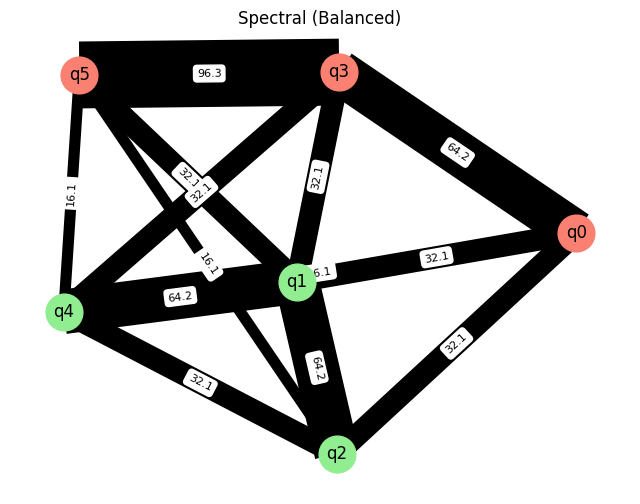


--- Kernighan-Lin (Multi-Restart) ---
Partition A: ['q0', 'q3', 'q5']
Partition B: ['q1', 'q2', 'q4']
Total Cost:            421.6199
Cross Weight Sum:      208.7506
Cross Penalty Sum:     272.1787
Max Cross Penalty:     42.5530
Cross Edge Count:      8
Internal Weight A:     160.5774
Internal Weight B:     160.5774
Internal Imbalance:    0.0000
Normalized Cross:      0.5136
Temporal Sum:          272.1787
Temporal Peak:         84.3031


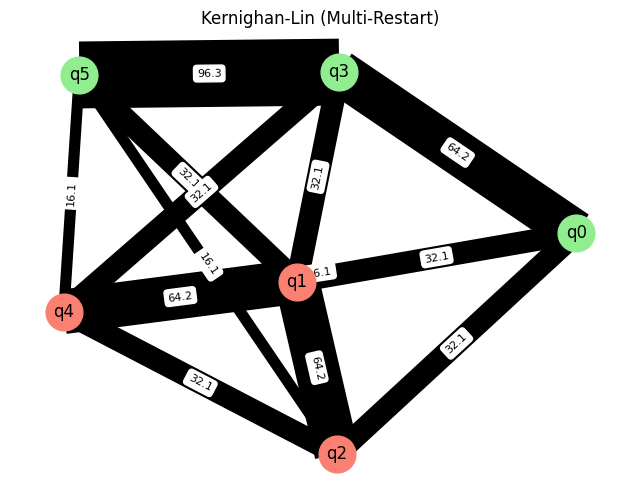


--- FM-Style Gain Refinement ---
Partition A: ['q1', 'q2', 'q4']
Partition B: ['q0', 'q3', 'q5']
Total Cost:            421.6199
Cross Weight Sum:      208.7506
Cross Penalty Sum:     272.1787
Max Cross Penalty:     42.5530
Cross Edge Count:      8
Internal Weight A:     160.5774
Internal Weight B:     160.5774
Internal Imbalance:    0.0000
Normalized Cross:      0.5136
Temporal Sum:          272.1787
Temporal Peak:         84.3031


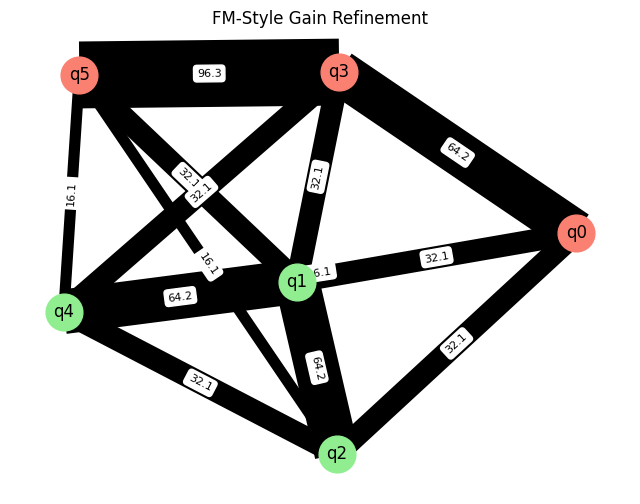


--- Exact Balanced Optimum ---
Partition A: ['q0', 'q3', 'q5']
Partition B: ['q1', 'q2', 'q4']
Total Cost:            421.6199
Cross Weight Sum:      208.7506
Cross Penalty Sum:     272.1787
Max Cross Penalty:     42.5530
Cross Edge Count:      8
Internal Weight A:     160.5774
Internal Weight B:     160.5774
Internal Imbalance:    0.0000
Normalized Cross:      0.5136
Temporal Sum:          272.1787
Temporal Peak:         84.3031


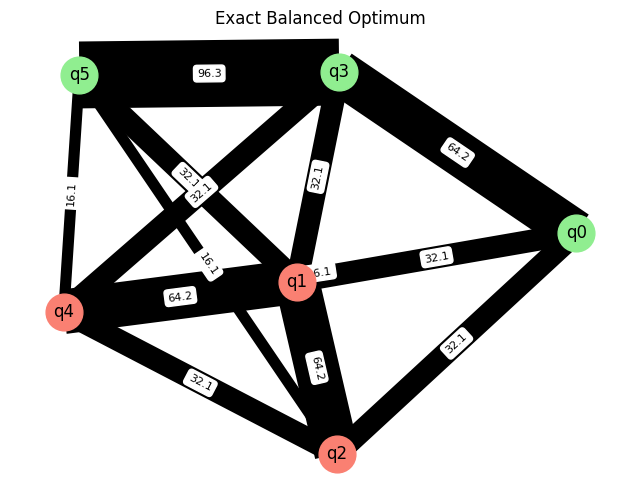


================ BEST RESULT ================
Best Algorithm: Spectral (Balanced)
Best Cost: 421.6199

========== OPTIMAL VS ARBITRARY COMPARISON ==========

--- Raw Costs ---
Optimal Total Cost:      421.6199
Arbitrary Total Cost:    587.8714
Optimal Cross Penalty:   272.1787
Arbitrary Cross Penalty: 366.9194
Optimal Temporal Sum:    272.1787
Arbitrary Temporal Sum:  366.9194
Optimal Temporal Peak:   84.3031
Arbitrary Temporal Peak: 119.6302

--- Improvement ---
Total Cost Improvement:    28.28%
Cross Penalty Improvement: 25.82%
Temporal Sum Improvement:  25.82%
Temporal Peak Improvement: 29.53%

Interpretation:
Using IBM-inspired duration/error-weighted costs, the optimal partition reduces estimated inter-ququart overhead by 28.28% relative to a random balanced assignment.


In [10]:
# =============================================================================
# IMPROVED QUBIT-TO-QUDIT / QUQUART MAPPING EXPERIMENT
# WITH IBM-INSPIRED HARDWARE GATE COSTS
#
# Major upgrades:
#   1. Proper balanced spectral partitioning
#   2. Multi-restart Kernighan-Lin
#   3. Stronger FM-style gain-based local refinement
#   4. Layer-aware circuit generation and temporal cost modeling
#   5. IBM-inspired hardware-aware gate costs
#   6. Richer cost function:
#        - total cross penalty
#        - bottleneck penalty
#        - internal load imbalance
#        - temporal sum
#        - temporal peak
#        - normalized cross penalty
#   7. Exact balanced optimum for small systems
#   8. Optional visualization
# =============================================================================

import random
import builtins
import itertools
from collections import defaultdict

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


# =============================================================================
# IBM-INSPIRED HARDWARE COST MODEL
#
# These are representative IBM-style values, not universal constants.
# Based on IBM-style calibration concepts:
#   - single-qubit X / SX are cheap
#   - two-qubit CX-like entanglers are much more expensive
#   - RZ / Z are treated as virtual with effectively zero hardware cost
#
# We convert duration + error into one scalar gate cost.
# =============================================================================

IBM_GATE_PROFILE = {
    # Single-qubit gates
    "X":     {"duration_ns": 35.5,      "error": 4.13e-4},
    "SX":    {"duration_ns": 35.5,      "error": 4.13e-4},
    "RZ":    {"duration_ns": 0.0,       "error": 0.0},
    "Z":     {"duration_ns": 0.0,       "error": 0.0},   # treated like virtual RZ

    # Two-qubit entangler proxy from representative IBM CX-style calibration data
    "CX":    {"duration_ns": 387.55125, "error": 8.755e-3},
    "CNOT":  {"duration_ns": 387.55125, "error": 8.755e-3},

    # For this model, treat CZ / iSWAP as generic 2-qubit entangling proxies
    "CZ":    {"duration_ns": 387.55125, "error": 8.755e-3},
    "iSWAP": {"duration_ns": 387.55125, "error": 8.755e-3},

    # SWAP approximated as 3 CX-like entanglers
    "SWAP":  {"duration_ns": 3 * 387.55125, "error": 3 * 8.755e-3},
}

IBM_REF_DURATION_NS = IBM_GATE_PROFILE["X"]["duration_ns"]
IBM_REF_ERROR = IBM_GATE_PROFILE["X"]["error"]

# Tune these if you want to emphasize latency vs reliability differently
DURATION_WEIGHT = 0.5
ERROR_WEIGHT = 0.5


def hardware_scalar_cost(gate_name):
    """
    Convert IBM-style duration + error into a normalized scalar cost.
    Everything is normalized relative to X.
    """
    profile = IBM_GATE_PROFILE[gate_name]

    duration_ratio = (
        profile["duration_ns"] / IBM_REF_DURATION_NS
        if IBM_REF_DURATION_NS > 0 else 0.0
    )

    error_ratio = (
        profile["error"] / IBM_REF_ERROR
        if IBM_REF_ERROR > 0 else 0.0
    )

    return DURATION_WEIGHT * duration_ratio + ERROR_WEIGHT * error_ratio


# These replace the old hand-set weights
GATE_BASE_WEIGHTS = {
    "CNOT": hardware_scalar_cost("CNOT"),
    "CZ": hardware_scalar_cost("CZ"),
    "SWAP": hardware_scalar_cost("SWAP"),
    "iSWAP": hardware_scalar_cost("iSWAP"),
}


# =============================================================================
# DEFAULT COST CONFIGURATION
# =============================================================================

DEFAULT_CONFIG = {
    # Extra penalty if an interaction must cross ququart boundaries
    "cross_penalty_multiplier": {
        "CNOT": 1.35,
        "CZ": 1.25,
        "SWAP": 1.60,
        "iSWAP": 1.30,
    },
    "alpha_total_cross": 1.00,
    "beta_bottleneck": 0.35,
    "gamma_internal_imbalance": 0.20,
    "delta_temporal_sum": 0.40,
    "epsilon_temporal_peak": 0.30,
    "zeta_normalized_cross": 0.75,
}


# =============================================================================
# RANDOM CIRCUIT GENERATION (LAYER-AWARE)
# =============================================================================

def generate_random_circuit(
    min_qubits=6,
    max_qubits=14,
    min_gates=20,
    max_gates=60,
    max_layers=None,
    seed=None
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    n = random.choice([q for q in range(min_qubits, max_qubits + 1) if q % 2 == 0])
    qubits = [f"q{i}" for i in range(n)]

    num_gates = random.randint(min_gates, max_gates)

    if max_layers is None:
        max_layers = max(4, n)

    circuit = []

    for _ in range(num_gates):
        q1, q2 = random.sample(qubits, 2)
        gate = random.choice(list(GATE_BASE_WEIGHTS.keys()))
        layer = random.randint(0, max_layers - 1)

        circuit.append({
            "q1": q1,
            "q2": q2,
            "gate": gate,
            "layer": layer
        })

    circuit.sort(key=lambda g: g["layer"])
    return qubits, circuit


# =============================================================================
# BUILD AGGREGATE INTERACTION GRAPH
# =============================================================================

def build_interaction_graph(qubits, circuit):
    G = nx.Graph()
    G.add_nodes_from(qubits)

    interactions = defaultdict(lambda: defaultdict(int))

    for gate_event in circuit:
        key = tuple(sorted((gate_event["q1"], gate_event["q2"])))
        interactions[key][gate_event["gate"]] += 1

    for (q1, q2), gate_dict in interactions.items():
        base_weight = builtins.sum(
            GATE_BASE_WEIGHTS[g] * count
            for g, count in gate_dict.items()
        )

        G.add_edge(
            q1,
            q2,
            weight=base_weight,
            gate_hist=dict(gate_dict)
        )

    return G, interactions


# =============================================================================
# BUILD PER-LAYER GRAPHS
# =============================================================================

def build_layer_graphs(qubits, circuit):
    layers = defaultdict(list)

    for gate_event in circuit:
        layers[gate_event["layer"]].append(gate_event)

    layer_graphs = {}

    for layer_idx, gates in layers.items():
        G = nx.Graph()
        G.add_nodes_from(qubits)

        pair_hist = defaultdict(lambda: defaultdict(int))

        for gate_event in gates:
            key = tuple(sorted((gate_event["q1"], gate_event["q2"])))
            pair_hist[key][gate_event["gate"]] += 1

        for (q1, q2), gate_dict in pair_hist.items():
            weight = builtins.sum(
                GATE_BASE_WEIGHTS[g] * count
                for g, count in gate_dict.items()
            )
            G.add_edge(
                q1,
                q2,
                weight=weight,
                gate_hist=dict(gate_dict)
            )

        layer_graphs[layer_idx] = G

    return layer_graphs


# =============================================================================
# HARDWARE-AWARE CROSSING PENALTY
# =============================================================================

def partition_gate_penalty(gate_hist, config):
    penalty = 0.0

    for gate, count in gate_hist.items():
        base = GATE_BASE_WEIGHTS[gate]
        multiplier = config["cross_penalty_multiplier"][gate]
        penalty += count * base * multiplier

    return penalty


# =============================================================================
# HELPER METRICS
# =============================================================================

def compute_internal_weight(graph, group):
    total = 0.0
    for u, v, data in graph.edges(data=True):
        if u in group and v in group:
            total += data["weight"]
    return total


def compute_partition_loads(graph, A, B):
    return compute_internal_weight(graph, A), compute_internal_weight(graph, B)


def compute_cross_stats(graph, A, B, config):
    cross_base_weights = []
    cross_penalties = []
    cross_edges = []

    for u, v, data in graph.edges(data=True):
        if (u in A and v in B) or (u in B and v in A):
            base_weight = data["weight"]
            penalty_weight = partition_gate_penalty(data.get("gate_hist", {}), config)

            cross_base_weights.append(base_weight)
            cross_penalties.append(penalty_weight)
            cross_edges.append((u, v, penalty_weight))

    return {
        "cross_weight_sum": builtins.sum(cross_base_weights),
        "cross_penalty_sum": builtins.sum(cross_penalties),
        "max_cross_penalty": max(cross_penalties) if cross_penalties else 0.0,
        "cross_edge_count": len(cross_edges),
        "cross_edges": cross_edges,
    }


def compute_temporal_cross_cost(layer_graphs, A, B, config):
    per_layer_costs = {}

    for layer_idx, layer_graph in layer_graphs.items():
        stats = compute_cross_stats(layer_graph, A, B, config)
        per_layer_costs[layer_idx] = stats["cross_penalty_sum"]

    temporal_sum = builtins.sum(per_layer_costs.values())
    temporal_peak = max(per_layer_costs.values()) if per_layer_costs else 0.0

    return temporal_sum, temporal_peak, per_layer_costs


# =============================================================================
# FULL COST BREAKDOWN
# =============================================================================

def cost_breakdown(graph, layer_graphs, A, B, config):
    cross_stats = compute_cross_stats(graph, A, B, config)

    internal_A, internal_B = compute_partition_loads(graph, A, B)
    internal_imbalance = abs(internal_A - internal_B)

    total_graph_weight = builtins.sum(
        data["weight"] for _, _, data in graph.edges(data=True)
    )

    normalized_cross = (
        cross_stats["cross_penalty_sum"] / total_graph_weight
        if total_graph_weight > 0 else 0.0
    )

    temporal_sum, temporal_peak, per_layer_costs = compute_temporal_cross_cost(
        layer_graphs, A, B, config
    )

    total_cost = (
        config["alpha_total_cross"] * cross_stats["cross_penalty_sum"]
        + config["beta_bottleneck"] * cross_stats["max_cross_penalty"]
        + config["gamma_internal_imbalance"] * internal_imbalance
        + config["delta_temporal_sum"] * temporal_sum
        + config["epsilon_temporal_peak"] * temporal_peak
        + config["zeta_normalized_cross"] * normalized_cross
    )

    return {
        "total_cost": total_cost,
        "cross_weight_sum": cross_stats["cross_weight_sum"],
        "cross_penalty_sum": cross_stats["cross_penalty_sum"],
        "max_cross_penalty": cross_stats["max_cross_penalty"],
        "cross_edge_count": cross_stats["cross_edge_count"],
        "internal_A": internal_A,
        "internal_B": internal_B,
        "internal_imbalance": internal_imbalance,
        "normalized_cross": normalized_cross,
        "temporal_sum": temporal_sum,
        "temporal_peak": temporal_peak,
        "per_layer_costs": per_layer_costs,
    }


def objective(graph, layer_graphs, A, B, config):
    return cost_breakdown(graph, layer_graphs, A, B, config)["total_cost"]


# =============================================================================
# RANDOM BALANCED PARTITION
# =============================================================================

def random_balanced_partition(nodes, rng=None):
    nodes = list(nodes)

    if rng is None:
        random.shuffle(nodes)
    else:
        rng.shuffle(nodes)

    half = len(nodes) // 2
    return set(nodes[:half]), set(nodes[half:])


# =============================================================================
# PROPER BALANCED SPECTRAL PARTITIONING
# =============================================================================

def spectral_partition_balanced(graph):
    nodes = list(graph.nodes())

    if len(nodes) == 2:
        return {nodes[0]}, {nodes[1]}

    L = nx.laplacian_matrix(
        graph,
        nodelist=nodes,
        weight="weight"
    ).astype(float).todense()

    eigenvalues, eigenvectors = np.linalg.eigh(L)
    fiedler_vector = np.asarray(eigenvectors[:, 1]).flatten()

    order = np.argsort(fiedler_vector)
    half = len(nodes) // 2

    A = {nodes[i] for i in order[:half]}
    B = {nodes[i] for i in order[half:]}

    return A, B


# =============================================================================
# MULTI-RESTART KERNIGHAN-LIN
# =============================================================================

def kernighan_lin_best_of_restarts(graph, layer_graphs, config, restarts=20, seed=None):
    rng = random.Random(seed)
    best = None

    for _ in range(restarts):
        A0, B0 = random_balanced_partition(graph.nodes(), rng=rng)

        A, B = nx.algorithms.community.kernighan_lin_bisection(
            graph,
            partition=(A0, B0),
            weight="weight"
        )

        A, B = set(A), set(B)
        score = objective(graph, layer_graphs, A, B, config)

        if best is None or score < best["score"]:
            best = {"A": A, "B": B, "score": score}

    return best["A"], best["B"]


# =============================================================================
# FM-STYLE GAIN-BASED LOCAL REFINEMENT
# =============================================================================

def swap_gain_estimate(graph, a, b, A, B):
    gain = 0.0

    for nbr in graph.neighbors(a):
        w = graph[a][nbr]["weight"]
        if nbr in A:
            gain += w
        elif nbr in B:
            gain -= w

    for nbr in graph.neighbors(b):
        w = graph[b][nbr]["weight"]
        if nbr in B:
            gain += w
        elif nbr in A:
            gain -= w

    if graph.has_edge(a, b):
        gain -= 2 * graph[a][b]["weight"]

    return gain


def fm_style_pair_refinement(graph, layer_graphs, config, initial_A, initial_B, max_passes=10):
    A = set(initial_A)
    B = set(initial_B)

    best_global_A = set(A)
    best_global_B = set(B)
    best_global_score = objective(graph, layer_graphs, A, B, config)

    for _ in range(max_passes):
        unlocked_A = set(A)
        unlocked_B = set(B)

        move_sequence = []
        current_A = set(A)
        current_B = set(B)

        while unlocked_A and unlocked_B:
            candidates = []

            for a in unlocked_A:
                for b in unlocked_B:
                    est_gain = swap_gain_estimate(graph, a, b, current_A, current_B)
                    candidates.append((est_gain, a, b))

            if not candidates:
                break

            candidates.sort(key=lambda x: x[0], reverse=True)
            _, a_star, b_star = candidates[0]

            current_A.remove(a_star)
            current_B.remove(b_star)

            current_A.add(b_star)
            current_B.add(a_star)

            unlocked_A.remove(a_star)
            unlocked_B.remove(b_star)

            current_score = objective(graph, layer_graphs, current_A, current_B, config)
            move_sequence.append((set(current_A), set(current_B), current_score))

        if not move_sequence:
            break

        best_prefix_A, best_prefix_B, best_prefix_score = min(
            move_sequence,
            key=lambda x: x[2]
        )

        if best_prefix_score < best_global_score:
            A, B = best_prefix_A, best_prefix_B
            best_global_A = set(A)
            best_global_B = set(B)
            best_global_score = best_prefix_score
        else:
            break

    return best_global_A, best_global_B


def multi_restart_fm_style(graph, layer_graphs, config, restarts=20, max_passes=10, seed=None):
    rng = random.Random(seed)
    best = None

    for _ in range(restarts):
        A0, B0 = random_balanced_partition(graph.nodes(), rng=rng)
        A, B = fm_style_pair_refinement(
            graph,
            layer_graphs,
            config,
            A0,
            B0,
            max_passes=max_passes
        )
        score = objective(graph, layer_graphs, A, B, config)

        if best is None or score < best["score"]:
            best = {"A": A, "B": B, "score": score}

    return best["A"], best["B"]


# =============================================================================
# EXACT BALANCED OPTIMUM (SMALL N ONLY)
# =============================================================================

def exact_balanced_partition(graph, layer_graphs, config, max_exact_qubits=10):
    nodes = list(graph.nodes())
    n = len(nodes)

    if n > max_exact_qubits:
        return None

    half = n // 2
    anchor = nodes[0]
    others = nodes[1:]

    best = None

    for combo in itertools.combinations(others, half - 1):
        A = {anchor, *combo}
        B = set(nodes) - A

        score = objective(graph, layer_graphs, A, B, config)

        if best is None or score < best["score"]:
            best = {"A": set(A), "B": set(B), "score": score}

    return best


# =============================================================================
# SUMMARIZE RESULTS
# =============================================================================

def summarize_partition(name, graph, layer_graphs, A, B, config):
    metrics = cost_breakdown(graph, layer_graphs, A, B, config)

    return {
        "algorithm": name,
        "A": sorted(A),
        "B": sorted(B),
        **metrics,
    }


def print_partition_summary(result):
    print(f"\n--- {result['algorithm']} ---")
    print("Partition A:", result["A"])
    print("Partition B:", result["B"])
    print(f"Total Cost:            {result['total_cost']:.4f}")
    print(f"Cross Weight Sum:      {result['cross_weight_sum']:.4f}")
    print(f"Cross Penalty Sum:     {result['cross_penalty_sum']:.4f}")
    print(f"Max Cross Penalty:     {result['max_cross_penalty']:.4f}")
    print(f"Cross Edge Count:      {result['cross_edge_count']}")
    print(f"Internal Weight A:     {result['internal_A']:.4f}")
    print(f"Internal Weight B:     {result['internal_B']:.4f}")
    print(f"Internal Imbalance:    {result['internal_imbalance']:.4f}")
    print(f"Normalized Cross:      {result['normalized_cross']:.4f}")
    print(f"Temporal Sum:          {result['temporal_sum']:.4f}")
    print(f"Temporal Peak:         {result['temporal_peak']:.4f}")


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_partition(graph, A, B, title):
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph, seed=42)

    nx.draw_networkx_nodes(graph, pos, nodelist=list(A), node_color="lightgreen", node_size=700)
    nx.draw_networkx_nodes(graph, pos, nodelist=list(B), node_color="salmon", node_size=700)

    widths = [max(1.0, data["weight"] / 2.0) for _, _, data in graph.edges(data=True)]
    nx.draw_networkx_edges(graph, pos, width=widths)
    nx.draw_networkx_labels(graph, pos)

    edge_labels = {
        (u, v): f"{data['weight']:.1f}"
        for u, v, data in graph.edges(data=True)
    }
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.show()


# =============================================================================
# MAIN EXPERIMENT DRIVER
# =============================================================================

def run_experiment(
    config=None,
    seed=67,
    kl_restarts=25,
    fm_restarts=25,
    fm_passes=10,
    max_exact_qubits=10,
    plot_results=True
):
    if config is None:
        config = DEFAULT_CONFIG

    qubits, circuit = generate_random_circuit(seed=seed)
    graph, interactions = build_interaction_graph(qubits, circuit)
    layer_graphs = build_layer_graphs(qubits, circuit)

    print("\n================ CIRCUIT SUMMARY ================")
    print("Number of qubits:", len(qubits))
    print("Total two-qubit gates:", len(circuit))
    print("Distinct interacting pairs:", len(interactions))
    print("Layers used:", len(layer_graphs))
    print("=================================================")

    print("\n============= IBM-INSPIRED GATE COSTS =============")
    for gate, weight in GATE_BASE_WEIGHTS.items():
        print(f"{gate}: {weight:.4f}")
    print("===================================================")

    results = {}

    A_sp, B_sp = spectral_partition_balanced(graph)
    results["Spectral (Balanced)"] = summarize_partition(
        "Spectral (Balanced)",
        graph,
        layer_graphs,
        A_sp,
        B_sp,
        config
    )

    A_kl, B_kl = kernighan_lin_best_of_restarts(
        graph,
        layer_graphs,
        config,
        restarts=kl_restarts,
        seed=seed
    )
    results["Kernighan-Lin (Multi-Restart)"] = summarize_partition(
        "Kernighan-Lin (Multi-Restart)",
        graph,
        layer_graphs,
        A_kl,
        B_kl,
        config
    )

    A_fm, B_fm = multi_restart_fm_style(
        graph,
        layer_graphs,
        config,
        restarts=fm_restarts,
        max_passes=fm_passes,
        seed=seed
    )
    results["FM-Style Gain Refinement"] = summarize_partition(
        "FM-Style Gain Refinement",
        graph,
        layer_graphs,
        A_fm,
        B_fm,
        config
    )

    exact = exact_balanced_partition(
        graph,
        layer_graphs,
        config,
        max_exact_qubits=max_exact_qubits
    )

    if exact is not None:
        results["Exact Balanced Optimum"] = summarize_partition(
            "Exact Balanced Optimum",
            graph,
            layer_graphs,
            exact["A"],
            exact["B"],
            config
        )

    print("\n================ RESULTS =================")

    for name, result in results.items():
        print_partition_summary(result)

        if plot_results:
            plot_partition(graph, set(result["A"]), set(result["B"]), name)

    best_name = min(results, key=lambda k: results[k]["total_cost"])

    print("\n================ BEST RESULT ================")
    print("Best Algorithm:", best_name)
    print(f"Best Cost: {results[best_name]['total_cost']:.4f}")
    print("=============================================")
    # -------------------------------------------------------------------------
    # OPTIMAL VS ARBITRARY SPLIT COMPARISON
    # -------------------------------------------------------------------------

    optimal_result = results[best_name]
    optimal_A = set(optimal_result["A"])
    optimal_B = set(optimal_result["B"])

    arbitrary_A, arbitrary_B = random_balanced_partition(
        graph.nodes(),
        rng=random.Random(seed + 999)
    )

    arbitrary_result = summarize_partition(
        "Arbitrary Balanced Split",
        graph,
        layer_graphs,
        arbitrary_A,
        arbitrary_B,
        config
    )

    print("\n========== OPTIMAL VS ARBITRARY COMPARISON ==========")

    print("\n--- Raw Costs ---")
    print(f"Optimal Total Cost:      {optimal_result['total_cost']:.4f}")
    print(f"Arbitrary Total Cost:    {arbitrary_result['total_cost']:.4f}")

    print(f"Optimal Cross Penalty:   {optimal_result['cross_penalty_sum']:.4f}")
    print(f"Arbitrary Cross Penalty: {arbitrary_result['cross_penalty_sum']:.4f}")

    print(f"Optimal Temporal Sum:    {optimal_result['temporal_sum']:.4f}")
    print(f"Arbitrary Temporal Sum:  {arbitrary_result['temporal_sum']:.4f}")

    print(f"Optimal Temporal Peak:   {optimal_result['temporal_peak']:.4f}")
    print(f"Arbitrary Temporal Peak: {arbitrary_result['temporal_peak']:.4f}")

    def percent_improvement(arbitrary_value, optimal_value):
        if arbitrary_value == 0:
            return 0.0
        return 100.0 * (arbitrary_value - optimal_value) / arbitrary_value

    print("\n--- Improvement ---")
    print(f"Total Cost Improvement:    {percent_improvement(arbitrary_result['total_cost'], optimal_result['total_cost']):.2f}%")
    print(f"Cross Penalty Improvement: {percent_improvement(arbitrary_result['cross_penalty_sum'], optimal_result['cross_penalty_sum']):.2f}%")
    print(f"Temporal Sum Improvement:  {percent_improvement(arbitrary_result['temporal_sum'], optimal_result['temporal_sum']):.2f}%")
    print(f"Temporal Peak Improvement: {percent_improvement(arbitrary_result['temporal_peak'], optimal_result['temporal_peak']):.2f}%")

    print("\nInterpretation:")
    print(
        "Using IBM-inspired duration/error-weighted costs, the optimal partition "
        f"reduces estimated inter-ququart overhead by "
        f"{percent_improvement(arbitrary_result['total_cost'], optimal_result['total_cost']):.2f}% "
        "relative to a random balanced assignment."
    )
    print("====================================================")

    return {
        "qubits": qubits,
        "circuit": circuit,
        "interactions": interactions,
        "graph": graph,
        "layer_graphs": layer_graphs,
        "results": results,
        "best_algorithm": best_name,
        "config": config
    }


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    run_experiment(
        kl_restarts=25,
        fm_restarts=25,
        fm_passes=10,
        max_exact_qubits=10,
        plot_results=True
    )